# Preliminary analysis of the data from Ferritienda's inventory 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

Infos regarding the data:
- The "referencia" column refers to the code for ferritienda's products internally 
- The "descripcion" column refers to the supplier's code for the product
- The brand for each product is the last word on the name of the product if not it is a generic product 


In [5]:
#We start by reading the csv file
data = pd.read_csv("data/inventario_ferritienda.csv", sep=";", encoding="latin1")
data = data.drop(data.columns[[0, 1, 2, 3]], axis=1)
# Mettre à jour les noms des colonnes
data.columns = [
    "Nombre", 
    "Código del producto o servicio", 
    "Referencia", 
    "Unidad de medida", 
    "Categoría", 
    "Descripción", 
    "Costo inicial", 
    "Precio base", 
    "Impuesto", 
    "Precio total", 
    "Precio general", 
    "Precio lista general 2023", 
    "Código cuenta contable", 
    "Cuenta contable", 
    "Código cuenta de inventario", 
    "Cuenta de inventario", 
    "Código cuenta de costo de venta", 
    "Cuenta de costo de venta", 
    "Código de barras 2", 
    "Código de barras 3", 
    "Código de barras"
]
data = data.drop(columns=["Código del producto o servicio", "Precio lista general 2023", "Código de barras 2", 
    "Código de barras 3" ])
# print(data.head())
print("first row", data.iloc[0])

first row Nombre                             ABRAZADERA 10-00 TITAN 3/8"
Referencia                                                   4
Unidad de medida                                        Unidad
Categoría                                          TORNILLERIA
Descripción                                                NaN
Costo inicial                                       720,000000
Precio base                                        1008,000000
Impuesto                                                  19.0
Precio total                                              1200
Precio general                                     1008,000000
Código cuenta contable                                  413505
Cuenta contable                                         Ventas
Código cuenta de inventario                           143505.0
Cuenta de inventario                               Inventarios
Código cuenta de costo de venta                       613505.0
Cuenta de costo de venta                 Cost

In [6]:
print(data.describe())


         Impuesto  Código cuenta contable  Código cuenta de inventario  \
count  4932.00000                  5017.0                       4965.0   
mean     18.97283                413505.0                     143505.0   
std       0.60525                     0.0                          0.0   
min       5.00000                413505.0                     143505.0   
25%      19.00000                413505.0                     143505.0   
50%      19.00000                413505.0                     143505.0   
75%      19.00000                413505.0                     143505.0   
max      19.00000                413505.0                     143505.0   

       Código cuenta de costo de venta  
count                           4965.0  
mean                          613505.0  
std                                0.0  
min                           613505.0  
25%                           613505.0  
50%                           613505.0  
75%                           613505.0  
max  

In [7]:
#missing values
print(data.isnull().sum())

Nombre                                0
Referencia                           15
Unidad de medida                      0
Categoría                           132
Descripción                        2548
Costo inicial                         0
Precio base                           0
Impuesto                             85
Precio total                          0
Precio general                        0
Código cuenta contable                0
Cuenta contable                       0
Código cuenta de inventario          52
Cuenta de inventario                 52
Código cuenta de costo de venta      52
Cuenta de costo de venta             52
Código de barras                    146
dtype: int64


In [12]:
#where refrencia is null 
print(data[data["Referencia"].isnull()])

                                                 Nombre Referencia  \
84                                                LLAVE        NaN   
3769                  LAMPARA ANTIPOLVO 1.20 MT MERCURY        NaN   
3793                          BOMBILLO LED 30W SILVANIA        NaN   
3912                                      CABLE 1X1 3MT        NaN   
4036                        CERRADURA POMO ALCOBA FANAL        NaN   
4091                 CANDADO CROMADO/ DORADO LLAVE CRUZ        NaN   
4125  ANTICORROSIVO PROTECCION ICO BLANCO 1/2 GALON ...        NaN   
4148    Yoyo Para Guadaï¿½adora Manual Th109-10 Bellota        NaN   
4387                            MANTENIMIENTO DE EQUIPO        NaN   
4399                 PALUSTRE MANGO PLASTICO NO 5 UDUKE        NaN   
4410         GUANTE CAUCHO INDUSTRIAL PREMIUM GOYA T 10        NaN   
4435                             DESCUENTOS COMERCIALES        NaN   
4510                        CANCAMO CERRADO N 00 RANGER        NaN   
4814      CINTA AISL

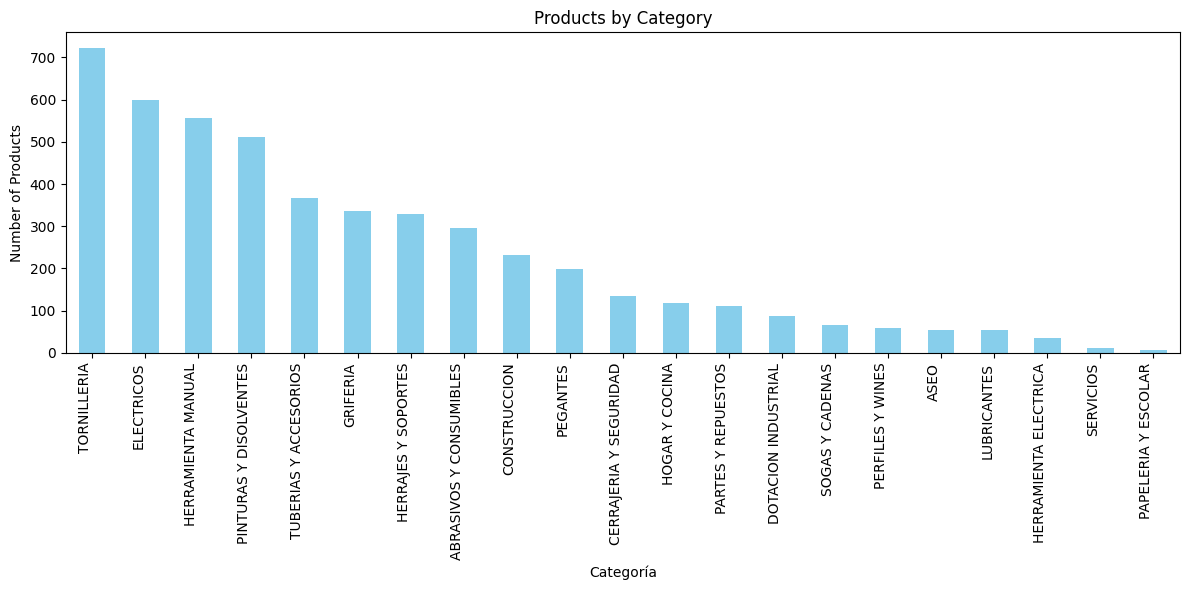

In [5]:
products_by_category = (
    data.groupby("Categoría")
    .size()
    .sort_values(ascending=False)
)


plt.figure(figsize=(12, 6))
products_by_category.plot(kind="bar", color="skyblue")
plt.title("Products by Category")
plt.xlabel("Categoría")
plt.ylabel("Number of Products")
plt.xticks(rotation=90, ha='right') 
plt.tight_layout()
plt.show()

In [6]:
# Categories with the most products
most_products = data["Categoría"].value_counts().head(10)
print(most_products)

Categoría
TORNILLERIA                723
ELECTRICOS                 599
HERRAMIENTA MANUAL         556
PINTURAS Y DISOLVENTES     511
TUBERIAS Y ACCESORIOS      367
GRIFERIA                   335
HERRAJES Y SOPORTES        330
ABRASIVOS Y CONSUMIBLES    295
CONSTRUCCION               233
PEGANTES                   198
Name: count, dtype: int64


In [7]:
#we are going to extract the brand for each product so that we can then go scrap all the information regarding the product on it's official website
#we extract the last word of the name of the product
data["Marca"] = data["Nombre"].str.split().str[-1]
brands = data["Marca"].unique()
for i in range(len(brands)):
    print(brands[i])

# plt.figure(figsize=(12, 6))
# brands.plot(kind="bar", color="skyblue")
# plt.title("Products by Brand")
# plt.xlabel("Marca")
# plt.ylabel("Number of Products")
# plt.xticks(rotation=90, ha='right')
# plt.tight_layout()


# print(data[["Nombre", "Marca"]].head())



3/8"
1/2"
TRUPER
1/2B
CRESCENT
UN
U
NEGRO
UNIDAD
PRETUL
39
GU10
ASTRO
MAXI
INCOLMA
TOOLS
GOYA
RANGER
HERMEX
SECURITY
17/8"
6
TESA
3M
1MT
PEQUEï¿½O
CODELCA
KONTIKI
DOC
11/2"
EXCALIBUR
ABRACOL
DEWALT
PREMIER
PORRAS
ESTANDAR
PEQUEï¿½AS
SUPER
8MT
OSBLACK/TITANIUM
BLANCO
FUELLE
L
8
9
PIEZAS
MERCURY
LLAVE
CORNETA
2.40MT
MM
P
ORIGINAL
X3"
3/4X1"
006
007
008
009
21/2
3
CORONA
GYD
5
GP
PINTE
AVE
STANLEY
GM
1M
CAJA
LOCTITE
UNIFER
ARCO
ENAR
LAVAMANOS
20G
750CC
BORDADA
LITEWAY
3/16X1/2"UN
5/32X1"UN
5/32X21/2"UN
1/2X2"UN
1/4X1"UN
1/4X11/2"UN
3/8X1"UN
5/16X11/4"UN
5/16X31/2"UN
7/16X11/2"UN
7/16X2"UN
8X1/2"50
8X1/2"DOC
50
COBRE
GRIVAL
11
12
X300MT
2.2MT
NICHOLSON
11/2
3/4"
1"
NAVIDEï¿½A
+CLAVO
CLAVO
10
16
20
24
28
36
4
44
52
60
72
88
7
FORTE
G
Oz
ML
CC
GALON
BOCHERINI
1/4"
ECO
GRIFOS
MULTIMARCA
COMPLETO
CUADRANTE
11/4"
2"
PAVCO
3/8
PLASGRIFOS
ONZ
RIOPLAST
CAPOTERA
PAï¿½O
BALON
PROCABLES
DESNUDO
5V
KILO
8V
1B
PEQUEï¿½A
TUPER
100
PAQUETE
30M
6MT
3MT
UDUKE
COAXIAL
5MT
LONA
LONAS
PALADA
MT
KLINTEK
RECICL

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5017 entries, 0 to 5016
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Nombre                           5017 non-null   object 
 1   Referencia                       5002 non-null   object 
 2   Unidad de medida                 5017 non-null   object 
 3   Categoría                        4885 non-null   object 
 4   Descripción                      2469 non-null   object 
 5   Costo inicial                    5017 non-null   object 
 6   Precio base                      5017 non-null   object 
 7   Impuesto                         4932 non-null   float64
 8   Precio total                     5017 non-null   object 
 9   Precio general                   5017 non-null   object 
 10  Código cuenta contable           5017 non-null   int64  
 11  Cuenta contable                  5017 non-null   object 
 12  Código cuenta de inv

We are going to get informations about each product using web scrapping and then we are going to analyze the data.

### Electricos category

In [9]:
df_electricos = data[data["Categoría"] == "ELECTRICOS"]
print(df_electricos.head())

                                    Nombre Referencia Unidad de medida  \
18              BOMBILLO DICROICO 110 GU10        282           Unidad   
19  BOMBILLO RECARGABLE PORTATIL 15W ASTRO       3430           Unidad   
50          CLAVIJA DOMESTICAV 10A CODELCA        736           Unidad   
51          CLAVIJA INDUSTRIAL 15A KONTIKI        737           Unidad   
68          EXTENSION CON POLO NARANJA 8MT        909           Unidad   

     Categoría Descripción Costo inicial   Precio base  Impuesto Precio total  \
18  ELECTRICOS        1961      0,000000   4202,000000      19.0         5000   
19  ELECTRICOS         NaN      0,000000  18992,000000      19.0        22600   
50  ELECTRICOS         NaN   2029,000000   3361,000000      19.0         4000   
51  ELECTRICOS         FC2   2313,000000   3529,000000      19.0         4200   
68  ELECTRICOS       45400      0,000000  18487,000000      19.0        22000   

   Precio general  Código cuenta contable Cuenta contable  \
18    4

we are going to get a random product from the "truper" brand to get the information about the product using web scrapping 

In [10]:
df_electricos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 599 entries, 18 to 5001
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Nombre                           599 non-null    object 
 1   Referencia                       596 non-null    object 
 2   Unidad de medida                 599 non-null    object 
 3   Categoría                        599 non-null    object 
 4   Descripción                      280 non-null    object 
 5   Costo inicial                    599 non-null    object 
 6   Precio base                      599 non-null    object 
 7   Impuesto                         591 non-null    float64
 8   Precio total                     599 non-null    object 
 9   Precio general                   599 non-null    object 
 10  Código cuenta contable           599 non-null    int64  
 11  Cuenta contable                  599 non-null    object 
 12  Código cuenta de inventar

In [11]:
truper_products = data[data["Marca"] == "TRUPER"].copy()
truper_products['Marca'] = truper_products['Marca'] + " " + truper_products['Descripción'].str.findall(r'\d+').str.join(" ")

In [12]:
sample_truper = truper_products.sample(1)
print(sample_truper)

                                     Nombre Referencia Unidad de medida  \
685  CALIBRADOR CABEZA DOBLE 200 LBS TRUPER       3009           Unidad   

              Categoría Descripción Costo inicial   Precio base  Impuesto  \
685  HERRAMIENTA MANUAL       18244  20077,000000  28571,000000      19.0   

    Precio total Precio general  Código cuenta contable Cuenta contable  \
685        33999   28571,000000                  413505          Ventas   

     Código cuenta de inventario Cuenta de inventario  \
685                     143505.0          Inventarios   

     Código cuenta de costo de venta Cuenta de costo de venta  \
685                         613505.0    Costos del inventario   

    Código de barras         Marca  
685    7506240608141  TRUPER 18244  


In [13]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
import time

In [14]:
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time

# Set up Selenium WebDriver
service = Service('/opt/homebrew/bin/chromedriver')  # Adjust to your path
driver = webdriver.Chrome(service=service)

try:
    # Step 1: Open the Truper Catalog page
    driver.get("https://www.truper.com/CatVigente/")
    time.sleep(3)  # Wait for the page to load fully

    # Step 2: Locate and interact with the search bar
    print("Locating the search bar...")

    # Try to locate the desktop search bar first
    try:
        search_bar = WebDriverWait(driver, 5).until(
            EC.element_to_be_clickable((By.ID, "buscador"))
        )
        print("Desktop search bar located.")
    except:
        # If desktop search bar is not found, try the mobile search bar
        try:
            search_bar = WebDriverWait(driver, 5).until(
                EC.element_to_be_clickable((By.ID, "buscadorMob"))
            )
            print("Mobile search bar located.")
        except:
            # If both fail, try the active menu search bar
            search_bar = WebDriverWait(driver, 5).until(
                EC.element_to_be_clickable((By.ID, "buscadorActiveMenu"))
            )
            print("Active menu search bar located.")

    # Step 3: Click and enter the product code
    print("Clicking on the search bar...")
    search_bar.click()
    print("Entering the product code...")
    search_bar.send_keys("11378")
    search_bar.send_keys(Keys.RETURN)
    print("Search executed.")

    # Step 4: Wait for the results or dropdown options
    print("Waiting for the results to load...")
    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.ID, "modulesDesk"))  # Adjust this if using mobile (`modulesMob`)
    )
    print("Search results loaded.")

finally:
    # Close the browser
    driver.quit()

Locating the search bar...
Desktop search bar located.
Clicking on the search bar...
Entering the product code...
Search executed.
Waiting for the results to load...
Search results loaded.


In [15]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.action_chains import ActionChains

# Set up Selenium WebDriver
service = Service('/opt/homebrew/bin/chromedriver')  # Adjust the path to your ChromeDriver
driver = webdriver.Chrome(service=service)

try:
    # Step 1: Open the catalog page
    driver.get("https://www.truper.com/CatVigente/")
    WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.ID, "buscador")))
    print("Page loaded.")

    # Step 2: Locate and interact with the search bar
    search_bar = driver.find_element(By.ID, "buscador")
    search_bar.click()
    search_bar.send_keys("11378")
    search_bar.submit()
    print("Search executed.")

    # Step 3: Wait for search results to load
    WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.CLASS_NAME, "result_desk")))
    print("Search results loaded.")

    # Step 4: Locate the fancy box link (PDF)
    pdf_link = WebDriverWait(driver, 10).until(
        EC.element_to_be_clickable((By.CSS_SELECTOR, "a.search-mod[data-fancybox]"))
    )
    print("PDF link located.")

    # Step 5: Scroll into view and click the PDF link
    ActionChains(driver).move_to_element(pdf_link).perform()
    pdf_link.click()
    print("PDF link clicked.")

    # Step 6: Wait for the fancy box content to load
    fancy_box = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, ".fancybox-content"))
    )
    print("Fancy box content loaded.")

    # Step 7: Wait for the PDF file to load
    pdf_frame = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "iframe[src*='.pdf']"))
    )
    pdf_url = pdf_frame.get_attribute("src")
    print(f"PDF loaded successfully: {pdf_url}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    driver.quit()

Page loaded.
Search executed.
Search results loaded.
PDF link located.
PDF link clicked.
Fancy box content loaded.
An error occurred: Message: 
Stacktrace:
0   chromedriver                        0x0000000100987184 cxxbridge1$str$ptr + 3626716
1   chromedriver                        0x000000010097f9d4 cxxbridge1$str$ptr + 3596076
2   chromedriver                        0x00000001003ec968 cxxbridge1$string$len + 89228
3   chromedriver                        0x0000000100430d50 cxxbridge1$string$len + 368756
4   chromedriver                        0x000000010046a5b4 cxxbridge1$string$len + 604376
5   chromedriver                        0x0000000100425568 cxxbridge1$string$len + 321676
6   chromedriver                        0x00000001004261b8 cxxbridge1$string$len + 324828
7   chromedriver                        0x00000001009529ac cxxbridge1$str$ptr + 3411716
8   chromedriver                        0x0000000100955ccc cxxbridge1$str$ptr + 3424804
9   chromedriver                        0x0

In [20]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from pdf2image import convert_from_path
import pytesseract
import requests
import os

# Set the path to Tesseract executable
pytesseract.pytesseract.tesseract_cmd = r'/usr/local/bin/tesseract'

# Selenium setup
service = Service('/opt/homebrew/bin/chromedriver')  # Adjust this path if necessary
driver = webdriver.Chrome(service=service)

try:
    # Step 1: Open the Truper Catalog page
    driver.get("https://www.truper.com/CatVigente/")
    WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.ID, "buscador"))
    )
    print("Page loaded.")

    # Step 2: Locate and interact with the search bar
    search_bar = driver.find_element(By.ID, "buscador")
    search_bar.send_keys("11378")
    search_bar.send_keys(Keys.RETURN)
    print("Search executed.")

    # Step 3: Locate the PDF link
    pdf_link = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "a.search-mod"))
    )
    pdf_url = pdf_link.get_attribute("href")
    print(f"PDF URL: {pdf_url}")

    # Step 4: Download the PDF
    response = requests.get(pdf_url)
    pdf_path = "truper_catalog.pdf"
    with open(pdf_path, "wb") as file:
        file.write(response.content)
    print("PDF downloaded.")

    # Step 5: Convert the PDF to images
    images = convert_from_path(pdf_path)
    for i, image in enumerate(images):
        image_path = f"page_{i+1}.jpg"
        image.save(image_path, "JPEG")
        print(f"Saved page {i+1} as an image.")

        # Step 6: Extract text from the image
        text = pytesseract.image_to_string(image)
        print(f"Text from page {i+1}:")
        print(text)

finally:
    driver.quit()

    # Cleanup downloaded files
    if os.path.exists("truper_catalog.pdf"):
        os.remove("truper_catalog.pdf")
    for i in range(len(images)):
        image_path = f"page_{i+1}.jpg"
        if os.path.exists(image_path):
            os.remove(image_path)

ModuleNotFoundError: No module named 'pdf2image'